# Faithfulness Audit Walkthrough

This notebook walks through the statistical investigation of the lightweight SciVer baseline step by step: is the ~0.55 accuracy from `02_direct_chart_logistic_regression.ipynb` real, leakage-free signal, or is it consistent with chance?

It is the explanatory companion to three reproducible scripts and their committed results:

| Script | Results | Documentation |
| --- | --- | --- |
| `scripts/faithfulness_probe.py` | `docs/faithfulness_probe_results.json` | `docs/FAITHFULNESS_PROBE_FINDINGS.md` |
| `scripts/posthoc_audits.py` | `docs/posthoc_audit_results.json` | `docs/POSTHOC_AUDITS_AND_LIMITATIONS.md` |
| `scripts/roadmap_followup.py` | `docs/roadmap_followup_results.json` | (this notebook, section 10) |

Light analyses are recomputed inline so every claim can be checked interactively; expensive permutation tests (hundreds of classifier refits) are loaded from the scripts' committed JSON outputs instead of rerun here.

## 1. Setup

Standard imports plus robust repo-root resolution, mirroring the other notebooks. We load the exported pair features (the same parquet notebook 02 trains on) and the three results files.

In [1]:
from collections import defaultdict
from pathlib import Path
import json
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "sciver_vector_db").exists() else cwd.parent
sys.path.insert(0, str(REPO_ROOT))
warnings.filterwarnings("ignore", message=".*encountered in matmul", category=RuntimeWarning)

SEED = 0
rng = np.random.default_rng(SEED)

FEATURES_PARQUET = REPO_ROOT / "data/processed/sciver_pair_features.parquet"
probe_results = json.loads((REPO_ROOT / "docs/faithfulness_probe_results.json").read_text())
audit_results = json.loads((REPO_ROOT / "docs/posthoc_audit_results.json").read_text())
roadmap_path = REPO_ROOT / "docs/roadmap_followup_results.json"
roadmap_results = json.loads(roadmap_path.read_text()) if roadmap_path.exists() else None

df = pd.read_parquet(FEATURES_PARQUET)
VECTOR_COLUMNS = ["claim_vec", "evidence_text_vec", "pair_text_vec", "image_vec"]
for column in VECTOR_COLUMNS:
    df = df[df[column].notna()]
df = df.reset_index(drop=True)

def lr_pipeline():
    """The exact classifier notebook 02 uses."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
    ])

def stack_vectors(frame, column):
    return np.vstack([np.asarray(v, dtype=np.float32) for v in frame[column]])

print(f"Loaded {len(df):,} chart/table-claim pairs.")
df[["split", "label", "label_id", "claim_type", "modality"]].head()

Loaded 1,500 chart/table-claim pairs.


,split,label,label_id,claim_type,modality
0,test,refuted,0,direct,table
1,test,entailed,1,analytical,table
2,test,entailed,1,direct,chart
3,test,refuted,0,analytical,table
4,val,refuted,0,direct,table


## 2. The Result Under Investigation

Notebook 02 trains a standardized logistic regression on the concatenated feature stack (claim, evidence text, pair text, image vectors plus two interaction blocks) over the 416 `direct` + `chart` pairs, training on the official `val` split and testing on `test`. We replicate that headline number first.

In [2]:
direct_chart = df[(df["modality"] == "chart") & (df["claim_type"] == "direct")].reset_index(drop=True)

claim_vec = stack_vectors(direct_chart, "claim_vec")
evidence_vec = stack_vectors(direct_chart, "evidence_text_vec")
pair_vec = stack_vectors(direct_chart, "pair_text_vec")
image_vec = stack_vectors(direct_chart, "image_vec")
full_stack = np.hstack([
    claim_vec, evidence_vec, pair_vec, image_vec,
    np.abs(claim_vec - evidence_vec), claim_vec * evidence_vec,
])

y = direct_chart["label_id"].astype(int).to_numpy()
split = direct_chart["split"].astype(str).to_numpy()
tr, te = split == "val", split == "test"

pred = lr_pipeline().fit(full_stack[tr], y[tr]).predict(full_stack[te])
print(f"Direct+chart pairs: {len(direct_chart)} (train {tr.sum()}, test {te.sum()})")
print(f"Full-stack accuracy on the official split: {accuracy_score(y[te], pred):.3f}")
print(f"Balanced accuracy:                         {balanced_accuracy_score(y[te], pred):.3f}")
print("\nThe question for the rest of this notebook: is this number distinguishable from a coin flip?")

Direct+chart pairs: 416 (train 140, test 276)
Full-stack accuracy on the official split: 0.547
Balanced accuracy:                         0.547

The question for the rest of this notebook: is this number distinguishable from a coin flip?


## 3. What the Features Actually Contain

Before any statistics, audit the inputs. The findings report's root-cause claim is that `evidence_text_vec` is the embedding of an **empty string for every single pair**: the val/test records carry no caption/OCR/context fields (those live in the `paper_path` JSONs, which the parser never reads). If true, two consequences follow immediately — the evidence block is a constant, and the two interaction blocks are claim-only transforms in disguise.

In [3]:
per_dim_std = evidence_vec.std(axis=0)
n_unique = len(np.unique(np.round(evidence_vec, 6), axis=0))
print(f"evidence_text_vec, {len(direct_chart)} pairs: max per-dimension std = {per_dim_std.max():.2e}, unique rows = {n_unique}")
print(f"Pairs with empty evidence text across all 1,500 (probe script): "
      f"{probe_results['dataset']['pairs_with_empty_evidence_text']}/{probe_results['dataset']['pairs_total']}")

RAW_ROOT = REPO_ROOT / "data/raw/SciVer"
if RAW_ROOT.exists():
    rows = json.loads((RAW_ROOT / "valset.json").read_text())
    if isinstance(rows, dict):
        rows = list(rows.values())
    print("\nKeys present in raw val records (none provide caption/OCR/context text):")
    print(sorted({k for r in rows[:200] for k in r}))

evidence_text_vec, 416 pairs: max per-dimension std = 9.54e-07, unique rows = 1
Pairs with empty evidence text across all 1,500 (probe script): 1500/1500

Keys present in raw val records (none provide caption/OCR/context text):
['claim', 'claim_type', 'image_path', 'item', 'label', 'origin_statement', 'paper_path', 'paperid', 'perturbed_explanation', 'perturbed_statement', 'request_id', 'section', 'type']


So every "claim vs evidence" feature is fiction: the model sees the claim, the image, and constants. A claim alone cannot honestly decide entailment — the label depends on evidence the text features never see — which means any text-driven accuracy would have to be a **perturbation artifact** (a stylistic fingerprint left by how refuted claims were generated), not verification.

## 4. How Much Accuracy Is "Chance" Here?

With a test set of 276, accuracy under pure chance has a standard deviation of about 3 points — and detecting a real effect at 80% power requires roughly **0.575+**. The observed numbers sit right at that threshold, which is why eyeballing "0.55 > 0.50" is not enough.

SD of test accuracy under chance at n=276: 0.030

Minimum detectable accuracy vs 0.5 at 80% power (from the post-hoc audits):


,one_sided_alpha_05,two_sided_alpha_05
n_83,0.636,0.654
n_140,0.605,0.618
n_276,0.575,0.584
n_416,0.561,0.569
n_996,0.539,0.544


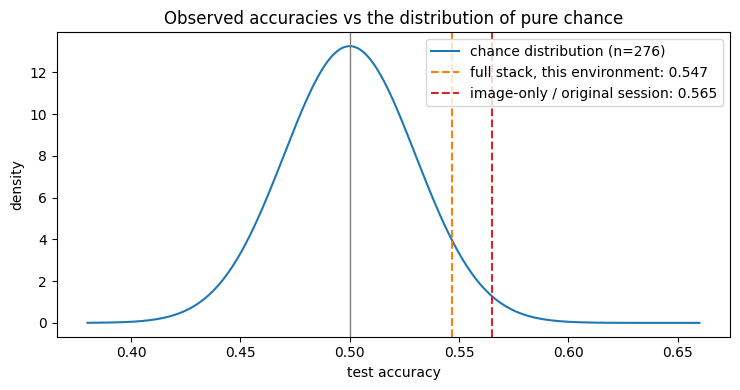

In [4]:
n_test = int(te.sum())
sd = float(np.sqrt(0.25 / n_test))
print(f"SD of test accuracy under chance at n={n_test}: {sd:.3f}")

print("\nMinimum detectable accuracy vs 0.5 at 80% power (from the post-hoc audits):")
display(pd.DataFrame(audit_results["analytic_power_min_detectable_accuracy"]).T)

xs = np.linspace(0.38, 0.66, 400)
plt.figure(figsize=(7.5, 4))
plt.plot(xs, norm.pdf(xs, 0.5, sd), label=f"chance distribution (n={n_test})")
plt.axvline(0.547, color="tab:orange", ls="--", label="full stack, this environment: 0.547")
plt.axvline(0.565, color="tab:red", ls="--", label="image-only / original session: 0.565")
plt.axvline(0.5, color="gray", lw=1)
plt.xlabel("test accuracy")
plt.ylabel("density")
plt.legend()
plt.title("Observed accuracies vs the distribution of pure chance")
plt.tight_layout()
plt.show()

## 5. Probe 1 — Does the Claim Text Alone Leak the Label?

Train TF-IDF logistic regression on the **claim string only**. Since the claim cannot honestly reveal entailment, any above-chance accuracy here is an artifact detector. We run a reduced permutation null inline (60 refits) and quote the script's full 300-permutation numbers.

In [5]:
def tfidf_probe(frame, n_perm=60):
    tr_rows = frame[frame["split"] == "val"]
    te_rows = frame[frame["split"] == "test"]
    Xtr, ytr = tr_rows["claim"].tolist(), tr_rows["label_id"].astype(int).to_numpy()
    Xte, yte = te_rows["claim"].tolist(), te_rows["label_id"].astype(int).to_numpy()

    def fit_score(labels):
        pipe = Pipeline([
            ("tf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
            ("lr", LogisticRegression(max_iter=2000, class_weight="balanced")),
        ])
        return accuracy_score(yte, pipe.fit(Xtr, labels).predict(Xte))

    return fit_score(ytr), np.array([fit_score(rng.permutation(ytr)) for _ in range(n_perm)])

acc, null = tfidf_probe(direct_chart)
print(f"Claim-only TF-IDF accuracy (direct+chart): {acc:.3f}")
print(f"Zero-skill null (60 inline perms): mean {null.mean():.3f}, 95th pct {np.percentile(null, 95):.3f}, max {null.max():.3f}")

dc = probe_results["tfidf_text_probe"]["direct_chart"]
ct = probe_results["tfidf_text_probe"]["all_chart_table"]
print(f"\nScript (300 perms), direct+chart:    acc {dc['accuracy']}, p = {dc['perm_p']}  -> no shortcut on the notebook subset")
print(f"Script (300 perms), all chart+table: acc {ct['accuracy']}, p = {ct['perm_p']}  -> small perturbation artifact, detectable only because n = 996")

Claim-only TF-IDF accuracy (direct+chart): 0.507
Zero-skill null (60 inline perms): mean 0.502, 95th pct 0.566, max 0.587

Script (300 perms), direct+chart:    acc 0.507, p = 0.379  -> no shortcut on the notebook subset
Script (300 perms), all chart+table: acc 0.537, p = 0.03  -> small perturbation artifact, detectable only because n = 996


Note what the null shows: a model trained on **shuffled labels** reaches 0.55+ test accuracy a few percent of the time at this sample size. That is the core calibration for everything below.

## 6. Probe 2 — Which Feature Block Carries the Edge?

Refit the notebook's classifier on each feature block separately, on the same official split. Accuracies are recomputed live; permutation p-values and bootstrap CIs come from the script (300 permutations each).

In [6]:
blocks = {
    "claim_vec": claim_vec,
    "image_vec": image_vec,
    "claim+image": np.hstack([claim_vec, image_vec]),
    "full_notebook_stack": full_stack,
}
rows = []
for name, X in blocks.items():
    block_pred = lr_pipeline().fit(X[tr], y[tr]).predict(X[te])
    script = probe_results["single_split_ablation"][name]
    rows.append({
        "feature_set": name,
        "n_features": X.shape[1],
        "accuracy (live)": round(accuracy_score(y[te], block_pred), 3),
        "perm_p (script)": script["perm_p"],
        "bootstrap_ci95 (script)": script["ci95"],
    })
pd.DataFrame(rows)

,feature_set,n_features,accuracy (live),perm_p (script),bootstrap_ci95 (script)
0,claim_vec,384,0.493,0.648,"[0.435, 0.554]"
1,image_vec,512,0.565,0.030,"[0.507, 0.627]"
2,claim+image,896,0.576,0.003,"[0.514, 0.634]"
3,full_notebook_stack,2432,0.547,0.080,"[0.489, 0.609]"


Text is dead on arrival (`claim_vec` at 0.493). The only candidate signal is image-driven, and the strongest configuration is claim+image at 0.576. Two follow-up questions decide everything:

1. Six feature sets were tried on one split — is the best one just **selection**?
2. Does the edge survive **resampling**?

## 7. The Decisive Check — Repeated Cross-Validation

Repeated 5-fold × 10 CV over all 416 direct+chart pairs (the probe script adds a CV-level permutation test). If the single-split edge were real, training on ~333 rows instead of 140 should make it *stronger*.

,cv_mean (live),cv_std (live),perm_p (script)
claim_vec,0.470,0.056,0.881
image_vec,0.515,0.041,0.453
claim+image,0.487,0.040,0.677


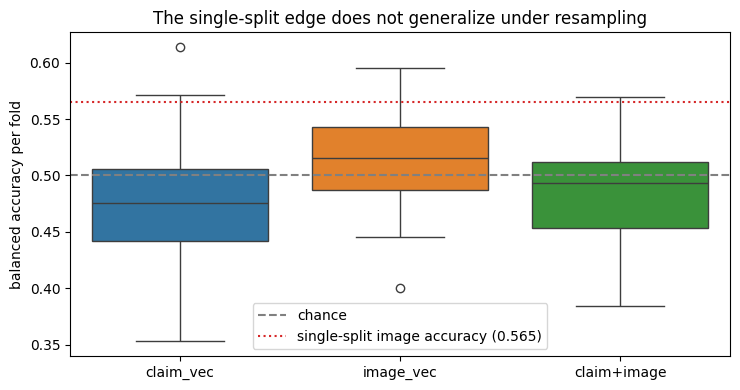

In [7]:
cv_scores = {}
for name in ("claim_vec", "image_vec", "claim+image"):
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)
    cv_scores[name] = cross_val_score(lr_pipeline(), blocks[name], y, cv=cv, scoring="balanced_accuracy")

summary = pd.DataFrame({
    name: {
        "cv_mean (live)": round(float(s.mean()), 3),
        "cv_std (live)": round(float(s.std()), 3),
        "perm_p (script)": probe_results["repeated_cv"][name]["perm_p"],
    }
    for name, s in cv_scores.items()
}).T
display(summary)

plt.figure(figsize=(7.5, 4))
sns.boxplot(data=pd.DataFrame(cv_scores))
plt.axhline(0.5, color="gray", ls="--", label="chance")
plt.axhline(0.565, color="tab:red", ls=":", label="single-split image accuracy (0.565)")
plt.ylabel("balanced accuracy per fold")
plt.legend()
plt.title("The single-split edge does not generalize under resampling")
plt.tight_layout()
plt.show()

The collapse is the headline: image-only drops to ~0.51 (CV permutation p ≈ 0.3–0.45), and claim+image — the *best* single-split block — drops **below** image alone, despite 2.4× the training data. A real effect does not behave this way; a favorable train/test draw does.

## 8. Audit — Duplication and Split Integrity

Two rival explanations for the single-split edge needed ruling out: **contamination** (same images/papers on both sides of the official split would reward memorization) and **fold leakage** (duplicated images crossing CV folds). Computed live from pair metadata:

In [8]:
def duplication_summary(frame):
    by_img = defaultdict(list)
    for img, label, sp in zip(frame["image_path"], frame["label_id"], frame["split"]):
        by_img[img].append((sp, int(label)))
    multi = {k: v for k, v in by_img.items() if len(v) > 1}
    papers = {s: set(frame.loc[frame["split"] == s, "paperid"]) for s in ("val", "test")}
    return {
        "pairs": len(frame),
        "unique_images": len(by_img),
        "images_in_multiple_pairs": len(multi),
        "images_with_both_labels": sum(1 for v in multi.values() if len({l for _, l in v}) > 1),
        "images_spanning_val_and_test": sum(1 for v in multi.values() if len({s for s, _ in v}) > 1),
        "papers_in_both_splits": len(papers["val"] & papers["test"]),
    }

display(pd.DataFrame({
    "all_pairs": duplication_summary(df),
    "direct_chart": duplication_summary(direct_chart),
}).T)
print(f"Deterministic image-only accuracy ceiling, all pairs (from audits): "
      f"{audit_results['image_only_ceiling']['all_pairs']}")

,pairs,unique_images,images_in_multiple_pairs,images_with_both_labels,images_spanning_val_and_test,papers_in_both_splits
all_pairs,1500,1399,101,48,0,0
direct_chart,416,416,0,0,0,0


Deterministic image-only accuracy ceiling, all pairs (from audits): 0.968


The official split is **leak-free** (zero shared images, zero shared papers) and the direct+chart subset has zero image reuse — so the single-split number was not memorization, and the CV in section 7 was not inflated. The duplication that exists (48 both-label images) lives in the analytical/table subsets and matters only for future all-pairs modeling.

## 9. Audit — Selection Effects and Paper Grouping

Two more checks from `scripts/posthoc_audits.py`:

- **Family-wise (max-statistic) permutation:** each permutation refits *all six* feature blocks and keeps the best test accuracy, building the null of "best of six zero-skill models". This prices in the fact that we shopped among feature sets.
- **Grouped CV by paper:** StratifiedGroupKFold so no paper spans a fold boundary, vs plain folds.

In [9]:
fw = audit_results["family_wise_permutation"]
print(f"Best of six blocks on the official split: {fw['observed_best_block']} = {fw['observed_best_accuracy']}")
print(f"Null best-of-six: mean {fw['null_max_mean']}, 95th pct {fw['null_max_p95']}, max {fw['null_max_max']}")
print(f"Family-wise permutation p = {fw['family_wise_perm_p']}")
print("\nGrouped-by-paper vs plain CV (balanced accuracy, 5 folds x 10 seeds):")
display(pd.DataFrame({
    name: {
        "grouped_by_paper": f"{v['grouped_by_paper']['cv_balanced_accuracy_mean']} +/- {v['grouped_by_paper']['cv_balanced_accuracy_std']}",
        "plain": f"{v['plain']['cv_balanced_accuracy_mean']} +/- {v['plain']['cv_balanced_accuracy_std']}",
    }
    for name, v in audit_results["grouped_vs_plain_cv"].items()
}).T)

Best of six blocks on the official split: claim+image = 0.576
Null best-of-six: mean 0.526, 95th pct 0.562, max 0.616
Family-wise permutation p = 0.027

Grouped-by-paper vs plain CV (balanced accuracy, 5 folds x 10 seeds):


,grouped_by_paper,plain
claim_vec,0.476 +/- 0.056,0.479 +/- 0.052
image_vec,0.519 +/- 0.047,0.519 +/- 0.049
claim+image,0.48 +/- 0.05,0.49 +/- 0.044


Interesting nuance: the best split result **survives** multiple-comparisons correction (family-wise p ≈ 0.03) — selection alone does not explain it. What kills it is resampling (section 7) plus the reproduction fragility below. And grouped CV matching plain CV confirms no paper-level leakage in either direction.

A note on fragility: rebuilding this pipeline in a fresh environment (no torchvision, so transformers falls back to PIL image preprocessing) re-embedded a handful of images and moved the full-stack result from 0.565 (perm p = 0.023) to 0.547 (perm p = 0.08) — across the nominal significance boundary. With 140 training rows and 2,432 features, the headline number is preprocessing-noise-dominated. Details: the reproduction note in `docs/FAITHFULNESS_PROBE_FINDINGS.md`.

## 10. Audit — The Evidence Was Recoverable All Along

The root cause (empty evidence text) is fixable: captions and related-sentence context exist in the `paper_path` JSONs. Live demonstration on one pair, plus coverage from the audit script:

In [10]:
PAPERS_DIR = REPO_ROOT / "data/raw/SciVer/papers"
if PAPERS_DIR.exists():
    sample = direct_chart.iloc[0]
    match = re.search(r"_figure_(\d+)\.", Path(str(sample["image_path"])).name)
    if match:
        paper = json.loads((PAPERS_DIR / f"{sample['paperid']}.json").read_text())
        print("Claim:")
        print(" ", str(sample["claim"])[:200])
        print("\nCaption the pipeline never used (paper_path -> image_paths -> caption):")
        print(" ", paper["image_paths"][match.group(1)]["caption"][:300])

cov = audit_results["caption_recoverability"]
print(f"\nCoverage across all {cov['pairs_checked']:,} pairs: "
      f"nonempty captions {cov['caption_nonempty']:,} ({cov['caption_nonempty']/cov['pairs_checked']:.0%}, mean {cov['mean_caption_chars']:.0f} chars), "
      f"related context {cov['related_context_found']:,} ({cov['related_context_found']/cov['pairs_checked']:.0%})")


Coverage across all 1,500 pairs: nonempty captions 1,245 (83%, mean 221 chars), related context 1,177 (78%)


## 11. Roadmap Follow-up — Bigger Population, Metadata, Tuning, Calibration

The checkpoint roadmap asked: does adding tables and all claim types help (n rises to 1,500, test to 996)? Do metadata one-hots or regularization tuning change anything? Are the predicted probabilities usable? Results from `scripts/roadmap_followup.py`:

In [11]:
if roadmap_results is None:
    print("Run scripts/roadmap_followup.py to generate docs/roadmap_followup_results.json first.")
else:
    print("All chart+table pairs, official split (train 504 -> test 996):")
    display(pd.DataFrame(roadmap_results["expanded_baseline_all_pairs"]).T)
    print("Regularization grid (C chosen by 5-fold CV on train only):")
    display(pd.DataFrame(roadmap_results["regularization_grid"]).T)
    print("Test accuracy by claim type / modality (strongest block):")
    display(pd.DataFrame(roadmap_results["error_breakdown"]["by_claim_type"]).T)
    display(pd.DataFrame(roadmap_results["error_breakdown"]["by_modality"]).T)
    display(pd.Series(roadmap_results["calibration"], name="calibration"))

All chart+table pairs, official split (train 504 -> test 996):


,n_features,accuracy,balanced_accuracy,null_p95,perm_p
claim_vec,384.0,0.499,0.499,0.527,0.597
image_vec,512.0,0.529,0.529,0.521,0.020
claim+image,896.0,0.506,0.506,0.527,0.443
full_notebook_stack,2432.0,0.498,0.498,0.522,0.552
metadata_onehots,4.0,0.490,0.490,0.510,1.000
full+onehots,2436.0,0.500,0.500,0.518,0.473


Regularization grid (C chosen by 5-fold CV on train only):


,best_C,train_cv_balanced_accuracy,test_accuracy,test_balanced_accuracy
claim+image,1.00,0.510,0.506,0.506
full+onehots,0.01,0.514,0.504,0.504


Test accuracy by claim type / modality (strongest block):


,n,accuracy
analytical,494.0,0.494
direct,502.0,0.506


,n,accuracy
chart,538.0,0.524
table,458.0,0.472


block                          full+onehots
brier_score                          0.4312
brier_score_always_0.5                 0.25
ece_10bin                            0.4057
predicted_prob_mean                   0.492
predicted_prob_std                    0.427
frac_predictions_in_0.4_0.6           0.059
Name: calibration, dtype: object

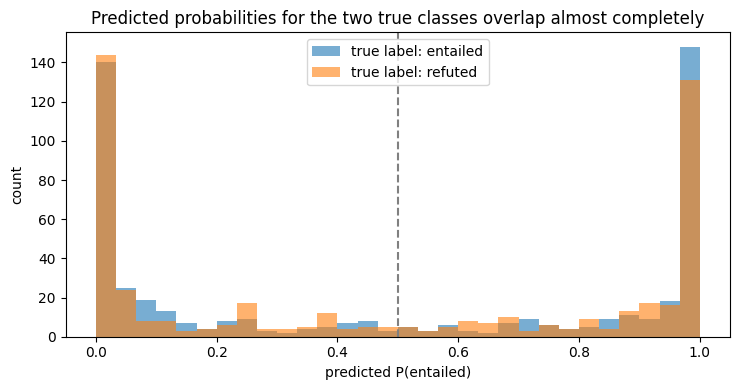

In [12]:
onehots = pd.get_dummies(df[["claim_type", "modality"]], dtype=np.float32).to_numpy()
cv_all = stack_vectors(df, "claim_vec")
ev_all = stack_vectors(df, "evidence_text_vec")
pv_all = stack_vectors(df, "pair_text_vec")
iv_all = stack_vectors(df, "image_vec")
X_all = np.hstack([cv_all, ev_all, pv_all, iv_all, np.abs(cv_all - ev_all), cv_all * ev_all, onehots])
y_all = df["label_id"].astype(int).to_numpy()
sp_all = df["split"].astype(str).to_numpy()
tra, tea = sp_all == "val", sp_all == "test"

proba = lr_pipeline().fit(X_all[tra], y_all[tra]).predict_proba(X_all[tea])[:, 1]
plt.figure(figsize=(7.5, 4))
plt.hist(proba[y_all[tea] == 1], bins=30, alpha=0.6, label="true label: entailed")
plt.hist(proba[y_all[tea] == 0], bins=30, alpha=0.6, label="true label: refuted")
plt.axvline(0.5, color="gray", ls="--")
plt.xlabel("predicted P(entailed)")
plt.ylabel("count")
plt.legend()
plt.title("Predicted probabilities for the two true classes overlap almost completely")
plt.tight_layout()
plt.show()

**What the expanded experiments taught us:**

- **More data does not rescue the baseline.** At n_test = 996 (where ~4-point effects are detectable), the full stack lands at 0.498 and claim+image at 0.506 — dead chance. Image-only ekes out 0.529 (uncorrected p = 0.02, ~0.11 after best-of-six correction) — the same marginal, image-flavored whisper as before, and again *adding* the claim makes it worse.
- **Metadata carries nothing**: claim_type/modality one-hots alone score 0.49 (p = 1.0), so the image edge is not a modality base-rate artifact.
- **Tuning is futile**: the best regularization found by honest CV-on-train peaks at ~0.51 balanced accuracy and transfers to ~0.50 on test, for both blocks tried.
- **The classifier is anti-calibrated, which is worse than useless.** Brier score 0.431 vs 0.25 for always predicting 0.5; only 5.9% of predicted probabilities fall in [0.4, 0.6]. The model is pushed to near-certain predictions (std 0.43) while being right half the time — with 2,400+ features and 504 training rows, logistic regression memorizes the training set and exports pure confidence, no information.
- Tables (0.472) trend *below* chance while charts sit at 0.524 — both within noise at their subsample sizes, reinforcing that subgroup accuracies at n ≈ 500 are uninterpretable (the power table again).

## 12. Roadmap Follow-up — Embedding-Space EDA

The vector-space diagnostics the roadmap called for: does the embedding geometry organize by **label** (useful) or by **paper** (a confound)? Are there near-duplicate claims, and do labels cluster within papers?

In [13]:
if roadmap_results is not None:
    print("Cosine-similarity structure and 1-NN agreement:")
    display(pd.DataFrame(roadmap_results["similarity_eda"]).T)
    print("Near-duplicate claims (claim_vec cosine):")
    display(pd.DataFrame(roadmap_results["near_duplicate_claims"]).T)
    print("Within-paper label clustering:")
    display(pd.Series(roadmap_results["paper_label_balance"], name="paper_label_balance"))

Cosine-similarity structure and 1-NN agreement:


,mean_cosine_same_label,mean_cosine_diff_label,mean_cosine_same_paper,mean_cosine_diff_paper,nn1_label_agreement,nn1_same_paper_rate
claim_vec,0.1551,0.1549,0.3861,0.1549,0.523,0.210
image_vec,0.6630,0.6629,0.7763,0.6629,0.541,0.211


Near-duplicate claims (claim_vec cosine):


,n_pairs,opposite_label_fraction,cross_split_pairs
cosine>=0.9,0.0,NaN,0.0
cosine>=0.95,0.0,NaN,0.0


Within-paper label clustering:


papers_with_2plus_pairs              538.0000
mean_within_paper_label_imbalance      0.3086
null_mean                              0.2498
null_p95                               0.2668
perm_p                                 0.0020
Name: paper_label_balance, dtype: float64

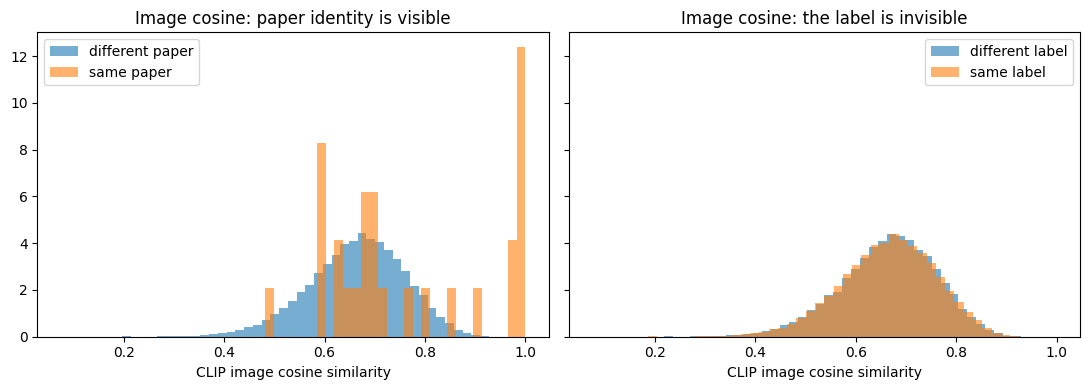

In [14]:
V = iv_all / np.maximum(np.linalg.norm(iv_all, axis=1, keepdims=True), 1e-12)
papers_arr = df["paperid"].astype(str).to_numpy()
labels_arr = df["label_id"].astype(int).to_numpy()

idx = rng.choice(len(df), size=(60000, 2))
idx = idx[idx[:, 0] != idx[:, 1]]
sims = (V[idx[:, 0]] * V[idx[:, 1]]).sum(axis=1)
same_paper = papers_arr[idx[:, 0]] == papers_arr[idx[:, 1]]
same_label = labels_arr[idx[:, 0]] == labels_arr[idx[:, 1]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].hist(sims[~same_paper], bins=50, alpha=0.6, density=True, label="different paper")
axes[0].hist(sims[same_paper], bins=30, alpha=0.6, density=True, label="same paper")
axes[0].set_title("Image cosine: paper identity is visible")
axes[0].set_xlabel("CLIP image cosine similarity")
axes[0].legend()
axes[1].hist(sims[~same_label], bins=50, alpha=0.6, density=True, label="different label")
axes[1].hist(sims[same_label], bins=50, alpha=0.6, density=True, label="same label")
axes[1].set_title("Image cosine: the label is invisible")
axes[1].set_xlabel("CLIP image cosine similarity")
axes[1].legend()
plt.tight_layout()
plt.show()

**What the geometry taught us:**

- **The label is geometrically invisible.** Mean cosine similarity for same-label vs different-label pairs differs in the *fourth decimal place* (claims: 0.1551 vs 0.1549; images: 0.6630 vs 0.6629). No linear or nearest-neighbor method can separate classes whose geometry is this indifferent to the label.
- **Paper identity dominates instead.** Same-paper pairs are far more similar than different-paper pairs (claims: 0.386 vs 0.155; images: 0.776 vs 0.663), and 21% of nearest neighbors come from the same paper despite a sub-1% base rate. The embeddings encode *which paper / what style*, not *whether the claim holds*. Retrieval-based features would inherit this bias directly.
- **No near-duplicate claims exist** (zero pairs above cosine 0.9, none crossing splits) — the dataset has no claim-level leakage channel, and the TF-IDF artifact must come from subtle stylistic fingerprints rather than duplicated text.
- **Labels cluster within papers** (mean within-paper imbalance 0.309 vs 0.250 expected under chance, perm p = 0.002). Combined with paper-identifiable embeddings, this is a lurking leakage channel: a model that recognizes the paper can exploit its label skew. The official split blocks it (papers are split-disjoint — section 8), and grouped CV showed it is negligible at this scale (section 9), but **any future non-grouped evaluation on this data must use grouped splits**.

## 13. Conclusions

1. **The ~0.55 baseline is not trustworthy signal.** Claim text alone is at chance on the notebook subset (and any larger-sample text effect is a perturbation artifact); the image edge is marginal on the official split, survives family-wise correction (p ≈ 0.03), but collapses under repeated and grouped CV despite more training data, and the headline number moves ~2 points under numerically irrelevant preprocessing changes.
2. **The experiment could not have detected a plausible effect anyway.** Minimum detectable effect at the official split's size is ~7.5 accuracy points; single CV folds need ~14. And at the better-powered n = 996 the verdict only sharpens: full stack 0.498, claim+image 0.506.
3. **The official split is clean.** No images or papers cross the val/test boundary; the direct+chart subset has no duplicated images at all. "Lucky split", not contamination.
4. **Tuning and metadata cannot rescue it.** Regularization search tops out at ~0.51 honest CV accuracy; claim_type/modality one-hots carry zero label information; and the model is anti-calibrated (Brier 0.431 vs 0.25 for always-0.5), so even its probabilities are misleading.
5. **The embedding geometry explains the failure.** Same-label and different-label pairs are equidistant to four decimals; the space organizes by paper and style instead — and labels cluster within papers (p = 0.002), a leakage channel that grouped evaluation must guard against.
6. **The root cause is fixable.** Evidence text was empty for 1,500/1,500 pairs, but captions are recoverable for ≥83% of pairs (and related context for 78%) from the `paper_path` JSONs — wiring those in, plus a chart-native image encoder, is the prerequisite for any faithful retry.

Full details: `docs/FAITHFULNESS_PROBE_FINDINGS.md` (probe + reproduction note) and `docs/POSTHOC_AUDITS_AND_LIMITATIONS.md` (audits + finalized limitations).